In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment

# STEP 1: Load the data

In [3]:
df = pd.read_csv("combined.csv")

# Assign a true rock-type label based on the Rock Name field
# (used later to evaluate how well K-Means recovered the true groups)
def assign_label(name):
    n = name.upper()
    if "RHYOLITE" in n:
        return "Rhyolite"
    elif "ANDESITE" in n:
        return "Andesite"
    elif "BASALT" in n:
        return "Basalt"

df["True Label"] = df["Rock Name"].apply(assign_label)

print("=== Sample Counts by Rock Type ===")
print(df["True Label"].value_counts())
print()

=== Sample Counts by Rock Type ===
True Label
Andesite    316
Rhyolite    240
Basalt      162
Name: count, dtype: int64



# STEP 2: Select features for clustering
### Here we use only SiO2 and TiO2 as a simple 2D example.
### Question for students: How many and which variables do you need to
### accurately separate the three rock types?


In [4]:
features = ["SiO2", "TiO2"]
X = df[features].values

# STEP 3: Standardize the features
### K-Means is distance-based, so features on different scales must be
### normalized so that no single variable dominates the clustering.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# STEP 4: Run K-Means with k=3 (we know there are 3 rock types)
### random_state ensures reproducibility; n_init runs the algorithm
### multiple times from different starting points and picks the best result.


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df["Cluster"] = kmeans.labels_


# STEP 5: Match K-Means cluster IDs to rock-type labels (optimal assignment)
### K-Means assigns arbitrary cluster numbers (0, 1, 2) with no guaranteed correspondence to rock types. We need a one-to-one mapping: each cluster gets exactly one rock-type label, and each label is used at most once.

## Approach — Hungarian algorithm (linear_sum_assignment):
###   1. Build a cost matrix C where C[i, j] = number of samples in cluster i that are NOT of rock type j (i.e., misclassification count).
###   2. Find the assignment of clusters to labels that minimises total cost.
###   This is guaranteed to find the globally optimal one-to-one mapping, unlike the greedy approach which can assign the same label to two clusters.

In [7]:
rock_types = ["Rhyolite", "Basalt", "Andesite"]   # the three label options
n = len(rock_types)

# Build cost matrix: rows = cluster IDs, columns = rock types
cost_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j, rock in enumerate(rock_types):
        # Cost = samples in cluster i that do NOT belong to rock type j
        in_cluster = df["Cluster"] == i
        cost_matrix[i, j] = (df.loc[in_cluster, "True Label"] != rock).sum()

# Hungarian algorithm: returns the row and column indices of the optimal match
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Build the final one-to-one cluster → label mapping
cluster_label_map = {row_ind[k]: rock_types[col_ind[k]] for k in range(n)}

df["Predicted Label"] = df["Cluster"].map(cluster_label_map)

print("=== Cluster → Rock Type Mapping ===")
for k, v in cluster_label_map.items():
    print(f"  Cluster {k}  →  {v}")
print()

=== Cluster → Rock Type Mapping ===
  Cluster 0  →  Andesite
  Cluster 1  →  Rhyolite
  Cluster 2  →  Basalt



# STEP 6: Evaluate the clustering
### Compare predicted cluster assignments to the true rock-type labels.
### Accuracy here reflects how well SiO2 + TiO2 alone separate the groups.


In [8]:
accuracy = (df["Predicted Label"] == df["True Label"]).mean()
print(f"=== Overall Accuracy: {accuracy:.1%} ===\n")
print("=== Classification Report ===")
print(classification_report(df["True Label"], df["Predicted Label"], zero_division=0))


=== Overall Accuracy: 75.3% ===

=== Classification Report ===
              precision    recall  f1-score   support

    Andesite       0.71      0.76      0.73       316
      Basalt       0.46      0.40      0.43       162
    Rhyolite       0.98      0.99      0.99       240

    accuracy                           0.75       718
   macro avg       0.72      0.71      0.72       718
weighted avg       0.74      0.75      0.75       718



# STEP 7: Visualize the clusters vs. the true labels (side-by-side)
### Left panel  → K-Means cluster assignments
### Right panel → True rock-type labels


0
1
2


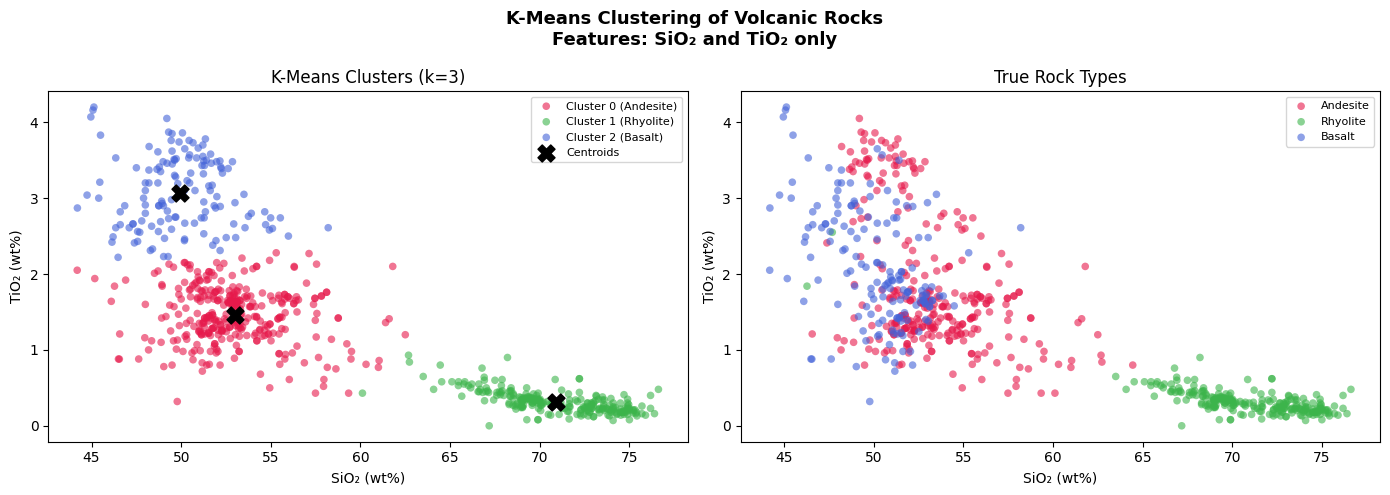

In [9]:
color_list = ["#e6194b", "#3cb44b", "#4363d8"]

colors_cluster = {}
colors_true    = {}
for key in cluster_label_map.keys():
    print(key)
    colors_cluster.update({key:color_list[key]})
    colors_true.update({cluster_label_map[key]:color_list[key]})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: K-Means clusters ---
ax = axes[0]
for cid, color in colors_cluster.items():
    mask = df["Cluster"] == cid
    ax.scatter(df.loc[mask, "SiO2"], df.loc[mask, "TiO2"],
               c=color, label=f"Cluster {cid} ({cluster_label_map[cid]})",
               alpha=0.6, edgecolors="none", s=30)
# Plot cluster centroids (transformed back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           c="black", marker="X", s=150, zorder=5, label="Centroids")
ax.set_xlabel("SiO₂ (wt%)")
ax.set_ylabel("TiO₂ (wt%)")
ax.set_title("K-Means Clusters (k=3)")
ax.legend(fontsize=8)

# --- Right: True labels ---
ax = axes[1]
for label, color in colors_true.items():
    mask = df["True Label"] == label
    ax.scatter(df.loc[mask, "SiO2"], df.loc[mask, "TiO2"],
               c=color, label=label, alpha=0.6, edgecolors="none", s=30)
ax.set_xlabel("SiO₂ (wt%)")
ax.set_ylabel("TiO₂ (wt%)")
ax.set_title("True Rock Types")
ax.legend(fontsize=8)

plt.suptitle("K-Means Clustering of Volcanic Rocks\nFeatures: SiO₂ and TiO₂ only",
             fontsize=13, fontweight="bold")
plt.tight_layout()

# =============================================================================
# STEP 8 (Student Exercise):
### Try adding more variables (e.g., Al2O3, Fe2O3, MGO, FEO, CAO) and
### re-run the clustering. How does accuracy change?
### Which combination of variables best separates the three rock types?
